### 线性回归的手动实现

In [23]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

### 模拟生成数据集
生成正态分布的输入特征

In [ ]:
def synthetic_data(w,b,num_example):
    """生成y = Xw + b +噪声。"""
    X = torch.normal(0,1,(num_example,len(w))) # 这里的1是标准差std 
    y = torch.matmul(X,w)+b
    y += torch.normal(0,0.01,y.shape) #加入噪声
    return X,y.reshape(-1,1)
true_w = torch.tensor([2,-3.4])
true_b = 4.2
features,labels = synthetic_data(true_w,true_b,1000)

In [25]:
print('features: ',features[:10],'\nlabels',labels[:10])

features:  tensor([[ 0.2199,  0.1067],
        [ 1.2844, -0.2080],
        [-0.6374, -0.6444],
        [ 0.2298, -0.3546],
        [-0.0943, -0.6098],
        [-0.6289, -0.4298],
        [ 0.6875, -1.4492],
        [ 0.1100,  0.5353],
        [ 1.6502, -0.7993],
        [-0.2541,  0.8122]]) 
labels tensor([[ 4.2859],
        [ 7.4782],
        [ 5.1051],
        [ 5.8744],
        [ 6.0829],
        [ 4.4013],
        [10.5048],
        [ 2.6012],
        [10.2246],
        [ 0.9327]])


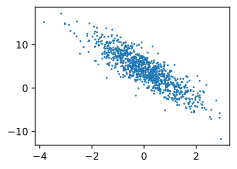

In [26]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),
                labels.detach().numpy(),1)

In [27]:
# 测试matmul

test_x = torch.normal(0,1,(10,3))
test_y = torch.normal(0,1,(3,10))
test_x,test_y,torch.matmul(test_x,test_y).shape

(tensor([[-1.8408,  0.8350,  1.6113],
         [-0.3449, -0.2433, -1.3495],
         [ 0.3464, -1.2996, -0.9018],
         [-0.1482, -1.1278,  0.3098],
         [-1.2914, -1.1487, -0.1176],
         [-1.7234,  0.4286,  0.1486],
         [-0.0161, -2.2557, -0.0911],
         [-1.0993,  0.1592,  0.9950],
         [-0.0630, -0.3053, -1.9576],
         [ 0.0732,  1.0624, -0.8545]]),
 tensor([[ 1.2155, -0.6347, -0.1507,  0.1356,  0.6063,  1.0656, -1.4898, -2.1755,
           1.2640,  0.7924],
         [ 1.2502, -0.0084,  2.8061, -0.6967,  0.0898,  0.5326,  0.9949,  1.5504,
          -0.5507,  1.4974],
         [ 1.6752, -2.1626,  0.1848, -0.1427,  0.1366, -1.0837,  0.5062, -0.6141,
          -1.1476, -0.0543]]),
 torch.Size([10, 10]))

In [ ]:
def data_iter(batch_size,features,labels):
    num = len(features) # num of features
    indices = list(range(num))
    # 打乱标号随机读取
    random.shuffle(indices)
    for i in range(0,num,batch_size):
        batch_indices = torch.tensor(indices[i:min(i+batch_size,num)])
        yield features[batch_indices],labels[batch_indices]

batch_size = 10

for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[-1.4254, -0.7937],
        [-0.6289, -0.4298],
        [ 1.2534, -0.1096],
        [ 1.6502, -0.7993],
        [-0.7119,  0.0462],
        [-0.6574,  1.6112],
        [ 1.9691,  1.6591],
        [-1.4579,  0.7120],
        [ 0.4594,  0.1548],
        [ 0.1846, -0.5264]]) 
 tensor([[ 4.0546],
        [ 4.4013],
        [ 7.0664],
        [10.2246],
        [ 2.6206],
        [-2.6056],
        [ 2.4967],
        [-1.1238],
        [ 4.5865],
        [ 6.3360]])


### 定义模型初始化参数

In [40]:
w = torch.normal(0,0.01,size=(2,1),requires_grad=True)
b = torch.zeros(1,requires_grad=True)

### 定义模型

In [30]:
def linreg(X,w,b):
    return torch.matmul(X,w)+b

### 定义损失函数

In [ ]:
def squared_loss(y_hat,y):
    """均方误差损失函数"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2 # 这/2是为了方便求导和求导之后的2抵消

### 定义优化算法

In [32]:
def sgd(params,lr,batch_size):
    """小批量梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

### 训练模型

In [41]:
lr = 0.01
epochs = 10
net = linreg
loss = squared_loss

for epoch in range(epochs):
    for X,y in data_iter(batch_size,features,labels):
        l = loss(net(X,w,b),y)
        
        l.sum().backward()
        sgd([w,b],lr,batch_size)
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(f'epoch  {epoch+1} , loss{float(train_l.mean()):f}')

epoch  1 , loss2.211694
epoch  2 , loss0.295153
epoch  3 , loss0.039544
epoch  4 , loss0.005349
epoch  5 , loss0.000762
epoch  6 , loss0.000146
epoch  7 , loss0.000062
epoch  8 , loss0.000050
epoch  9 , loss0.000049
epoch  10 , loss0.000049


In [44]:
print(f'w的误差: {true_w - w.reshape(true_w.shape)}')
print(f'b误差: {true_b - b}')

w的误差: tensor([-4.8399e-05, -1.2827e-04], grad_fn=<SubBackward0>)
b误差: tensor([9.1553e-05], grad_fn=<RsubBackward1>)


In [50]:
# test
x = torch.normal(0,1,(2,1),requires_grad=True)
y = x.norm()**2
y.backward()
x,y,x.grad

(tensor([[0.6042],
         [0.2600]], requires_grad=True),
 tensor(0.4327, grad_fn=<PowBackward0>),
 tensor([[1.2084],
         [0.5201]]))